<a href="https://colab.research.google.com/github/Harishree2005/Hari-Shree-P/blob/main/Phase1_EDA_Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

In [60]:
# Load dataset
import pandas as pd

url = "https://raw.githubusercontent.com/Harishree2005/Hari-Shree-P/main/bank_marketing_test.csv"

df = pd.read_csv(url)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,46,blue-collar,married,basic.6y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [61]:
# Dataset information
print("Shape:",df.shape)
display(df.head())
display(df.info())
display(df.describe())
display(df.describe(include='object'))
print("Columns:",df.columns.tolist())
print("Unique values:")
display(df.nunique())

Shape: (8237, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,46,blue-collar,married,basic.6y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8237 entries, 0 to 8236
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8237 non-null   int64  
 1   job             8237 non-null   object 
 2   marital         8237 non-null   object 
 3   education       8237 non-null   object 
 4   default         8237 non-null   object 
 5   housing         8237 non-null   object 
 6   loan            8237 non-null   object 
 7   contact         8237 non-null   object 
 8   month           8237 non-null   object 
 9   day_of_week     8237 non-null   object 
 10  duration        8237 non-null   int64  
 11  campaign        8237 non-null   int64  
 12  pdays           8237 non-null   int64  
 13  previous        8237 non-null   int64  
 14  poutcome        8237 non-null   object 
 15  emp.var.rate    8237 non-null   float64
 16  cons.price.idx  8237 non-null   float64
 17  cons.conf.idx   8237 non-null   f

None

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,8237.000000,8237.000000,8237.00000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000
mean,40.116547,256.007648,2.60471,962.228724,0.174335,0.070147,93.577806,-40.545320,3.608206,5166.589790
std,10.465328,259.728737,2.91562,187.533881,0.500565,1.574685,0.582138,4.623626,1.735931,72.470977
min,17.000000,4.000000,1.00000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,101.000000,1.00000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,179.000000,2.00000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000
75%,47.000000,316.000000,3.00000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,89.000000,4918.000000,43.00000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.000000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,8237,8237,8237,8237,8237,8237,8237,8237,8237,8237,8237
unique,12,4,8,2,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,mon,nonexistent,no
freq,2115,5041,2477,6480,4262,6822,5215,2751,1743,7113,7309


Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Unique values:


,0
age,72
job,12
marital,4
education,8
default,2
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [62]:
# Missing values
print(df.isnull().sum())
for c in df.select_dtypes(include='number').columns:
    df[c]=df[c].fillna(df[c].median())
for c in df.select_dtypes(exclude='number').columns:
    if df[c].isnull().any():
        df[c]=df[c].fillna(df[c].mode()[0])
print("Missing after handling:")
print(df.isnull().sum().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Missing after handling:
0


In [63]:
# Data Cleaning
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()
for c in df.select_dtypes(include='object').columns:
    df[c]=df[c].astype(str).str.strip().str.lower()
print(df.shape)

Duplicates: 2
(8235, 21)


In [64]:
# Data Transformation (Label Encoding)
df_trans=df.copy()
encoders={}
for c in df_trans.select_dtypes(include='object').columns:
    le=LabelEncoder()
    df_trans[c]=le.fit_transform(df_trans[c])
    encoders[c]=le
df_trans.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,41,1,1,7,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,25,7,2,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,35,1,1,1,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,46,1,1,1,1,2,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


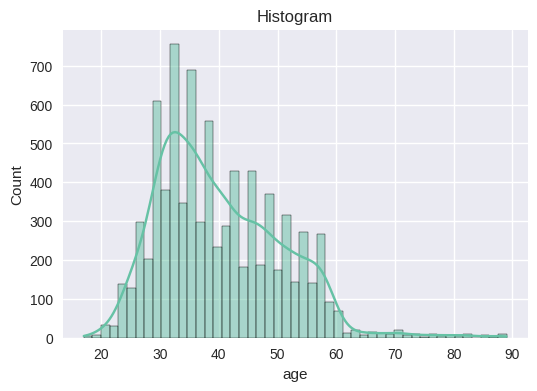

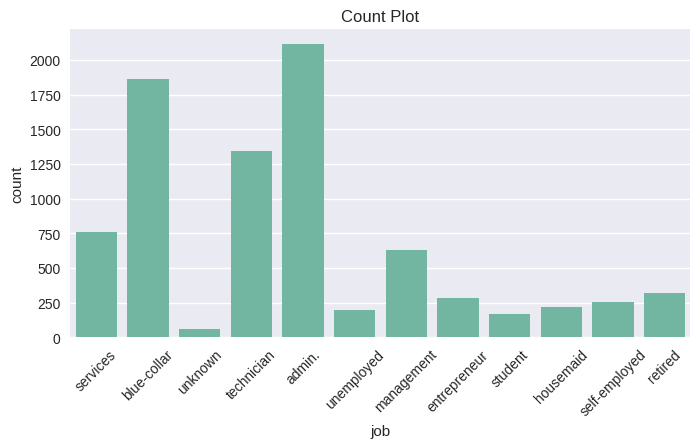

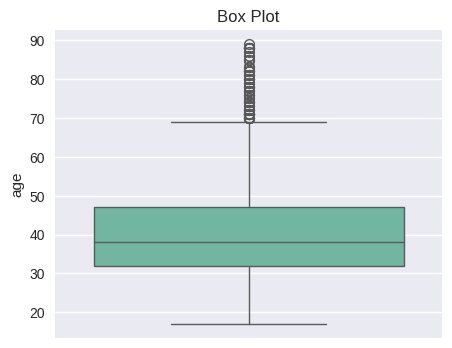

In [65]:
# Univariate Analysis
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns

if len(num)>0:
    plt.figure(figsize=(6,4));sns.histplot(df[num[0]],kde=True);plt.title("Histogram");plt.show()
if len(cat)>0:
    plt.figure(figsize=(8,4));sns.countplot(x=df[cat[0]]);plt.xticks(rotation=45);plt.title("Count Plot");plt.show()
if len(num)>0:
    plt.figure(figsize=(5,4));sns.boxplot(y=df[num[0]]);plt.title("Box Plot");plt.show()

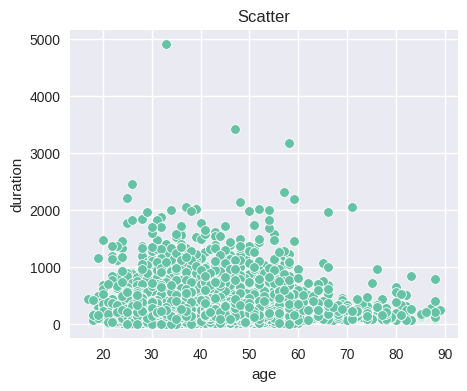

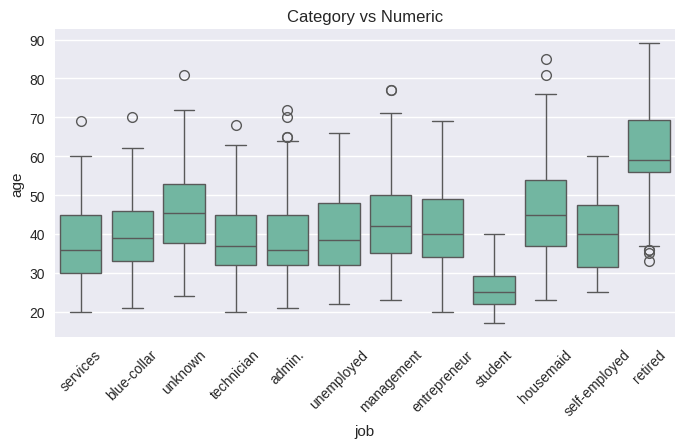

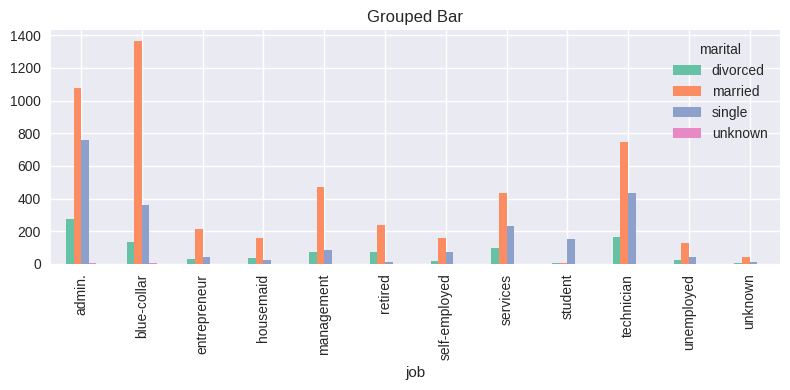

In [66]:
# Bivariate Analysis
if len(num)>=2:
    plt.figure(figsize=(5,4));sns.scatterplot(x=df[num[0]],y=df[num[1]]);plt.title("Scatter");plt.show()
if len(cat)>0 and len(num)>0:
    plt.figure(figsize=(8,4));sns.boxplot(x=df[cat[0]],y=df[num[0]]);plt.xticks(rotation=45);plt.title("Category vs Numeric");plt.show()
if len(cat)>=2:
    ct=pd.crosstab(df[cat[0]],df[cat[1]])
    ct.plot(kind='bar',figsize=(8,4))
    plt.title("Grouped Bar");plt.tight_layout();plt.show()

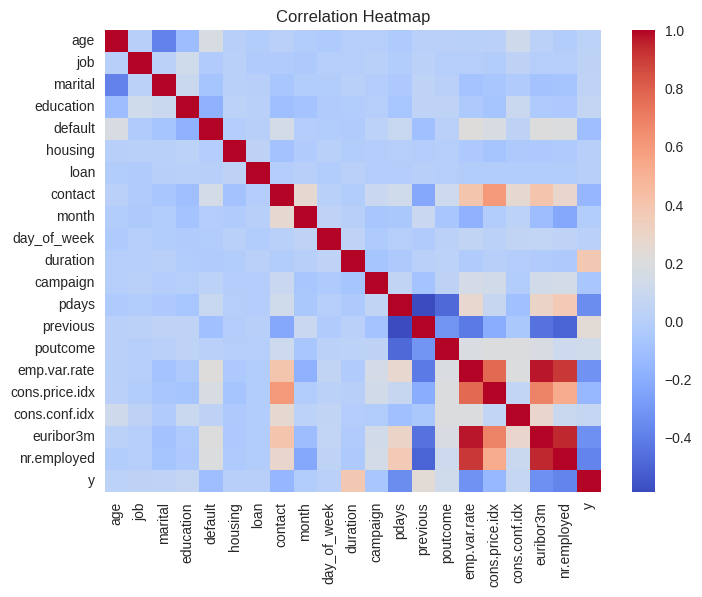

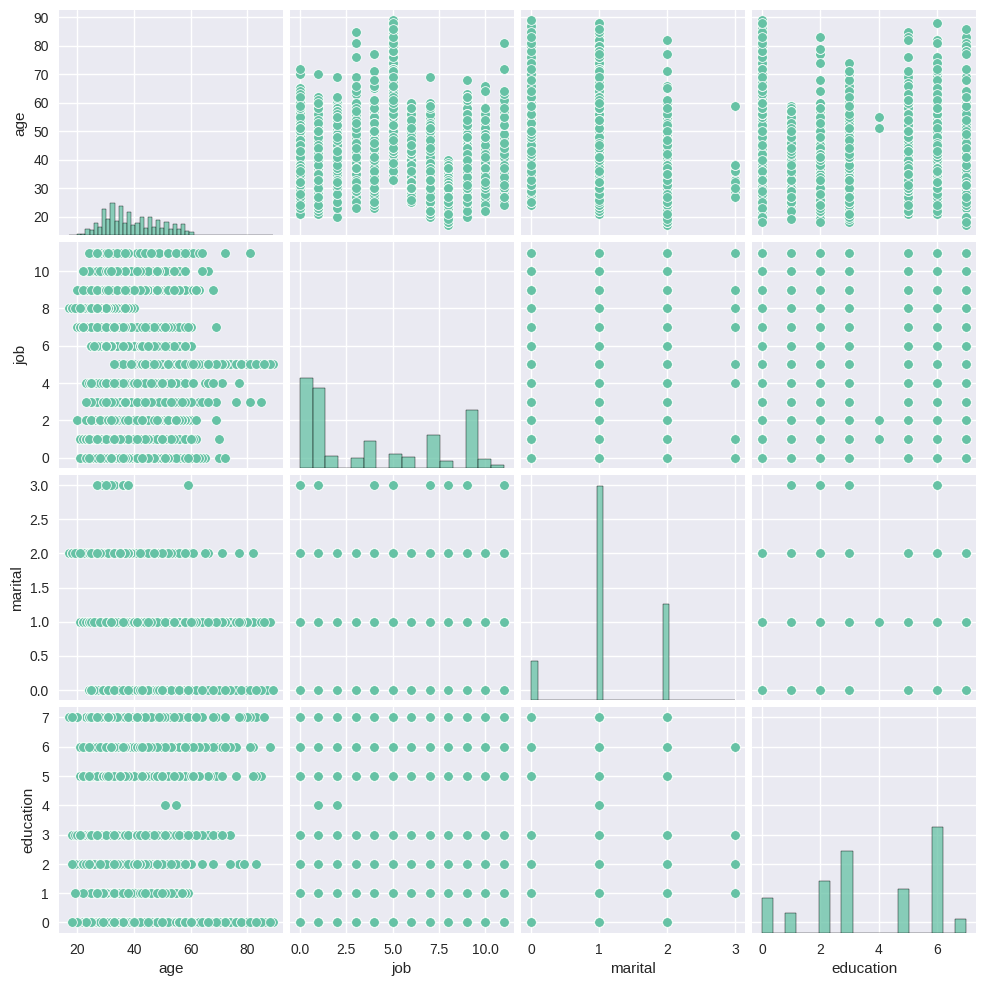

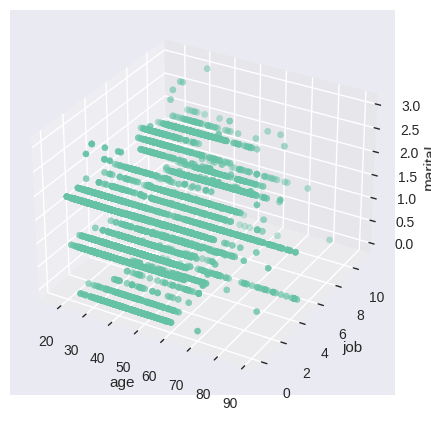

In [67]:
# Multivariate Analysis
plt.figure(figsize=(8,6))
sns.heatmap(df_trans.corr(numeric_only=True),annot=False,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df_trans.select_dtypes(include='number').iloc[:,:min(4,len(df_trans.select_dtypes(include='number').columns))])
plt.show()

if len(df_trans.select_dtypes(include='number').columns)>=3:
    from mpl_toolkits.mplot3d import Axes3D
    cols=df_trans.select_dtypes(include='number').columns[:3]
    fig=plt.figure(figsize=(6,5))
    ax=fig.add_subplot(111,projection='3d')
    ax.scatter(df_trans[cols[0]],df_trans[cols[1]],df_trans[cols[2]])
    ax.set_xlabel(cols[0]);ax.set_ylabel(cols[1]);ax.set_zlabel(cols[2])
    plt.show()

In [68]:
# Conclusion
print('Phase 1 completed successfully.')
print('Tasks completed:')
print('- Dataset Loading')
print('- Statistical Analysis')
print('- Missing Value Handling')
print('- Data Cleaning')
print('- Data Transformation')
print('- Univariate Analysis (3)')
print('- Bivariate Analysis (3)')
print('- Multivariate Analysis (3)')

Phase 1 completed successfully.
Tasks completed:
- Dataset Loading
- Statistical Analysis
- Missing Value Handling
- Data Cleaning
- Data Transformation
- Univariate Analysis (3)
- Bivariate Analysis (3)
- Multivariate Analysis (3)


# Phase 2 - Statistical Analysis and Clustering

This phase extends the exploratory analysis from Phase 1 by performing 1D, 2D and 3D statistical analyses, followed by K-Means and Hierarchical clustering.

In [69]:
# 1D Statistical Analysis
# Select numerical columns
numeric_cols = df.select_dtypes(include='number').columns
# Calculate descriptive statistics
one_d_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max(),
    'Variance': df[numeric_cols].var(),
    'Standard Deviation': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})
display(one_d_stats.round(3))

,Mean,Median,Mode,Minimum,Maximum,Variance,Standard Deviation,Skewness,Kurtosis
age,40.111,38.000,32.000,17.000,89.000,109.407,10.460,0.784,0.823
duration,256.051,179.000,71.000,4.000,4918.000,67467.114,259.744,3.556,26.515
campaign,2.605,2.000,1.000,1.000,43.000,8.502,2.916,5.017,39.857
pdays,962.220,999.000,999.000,0.000,999.000,35177.171,187.556,-4.904,22.054
previous,0.174,0.000,0.000,0.000,6.000,0.251,0.501,3.835,19.815
emp.var.rate,0.070,1.100,1.400,-3.400,1.400,2.479,1.574,-0.711,-1.077
cons.price.idx,93.578,93.444,93.994,92.201,94.767,0.339,0.582,-0.199,-0.884
cons.conf.idx,-40.548,-41.800,-36.400,-50.800,-26.900,21.358,4.621,0.342,-0.290
euribor3m,3.608,4.857,4.857,0.634,5.000,3.013,1.736,-0.693,-1.428
nr.employed,5166.600,5191.000,5228.100,4963.600,5228.100,5250.159,72.458,-1.034,-0.027


In [70]:
# Five-number summary
five_number_summary = df[numeric_cols].describe().T[
    ['min', '25%', '50%', '75%', 'max']
]
display(five_number_summary)

,min,25%,50%,75%,max
age,17.000,32.000,38.000,47.000,89.000
duration,4.000,101.000,179.000,316.000,4918.000
campaign,1.000,1.000,2.000,3.000,43.000
pdays,0.000,999.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,0.000,6.000
emp.var.rate,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,92.201,93.075,93.444,93.994,94.767
cons.conf.idx,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,0.634,1.344,4.857,4.961,5.000
nr.employed,4963.600,5099.100,5191.000,5228.100,5228.100


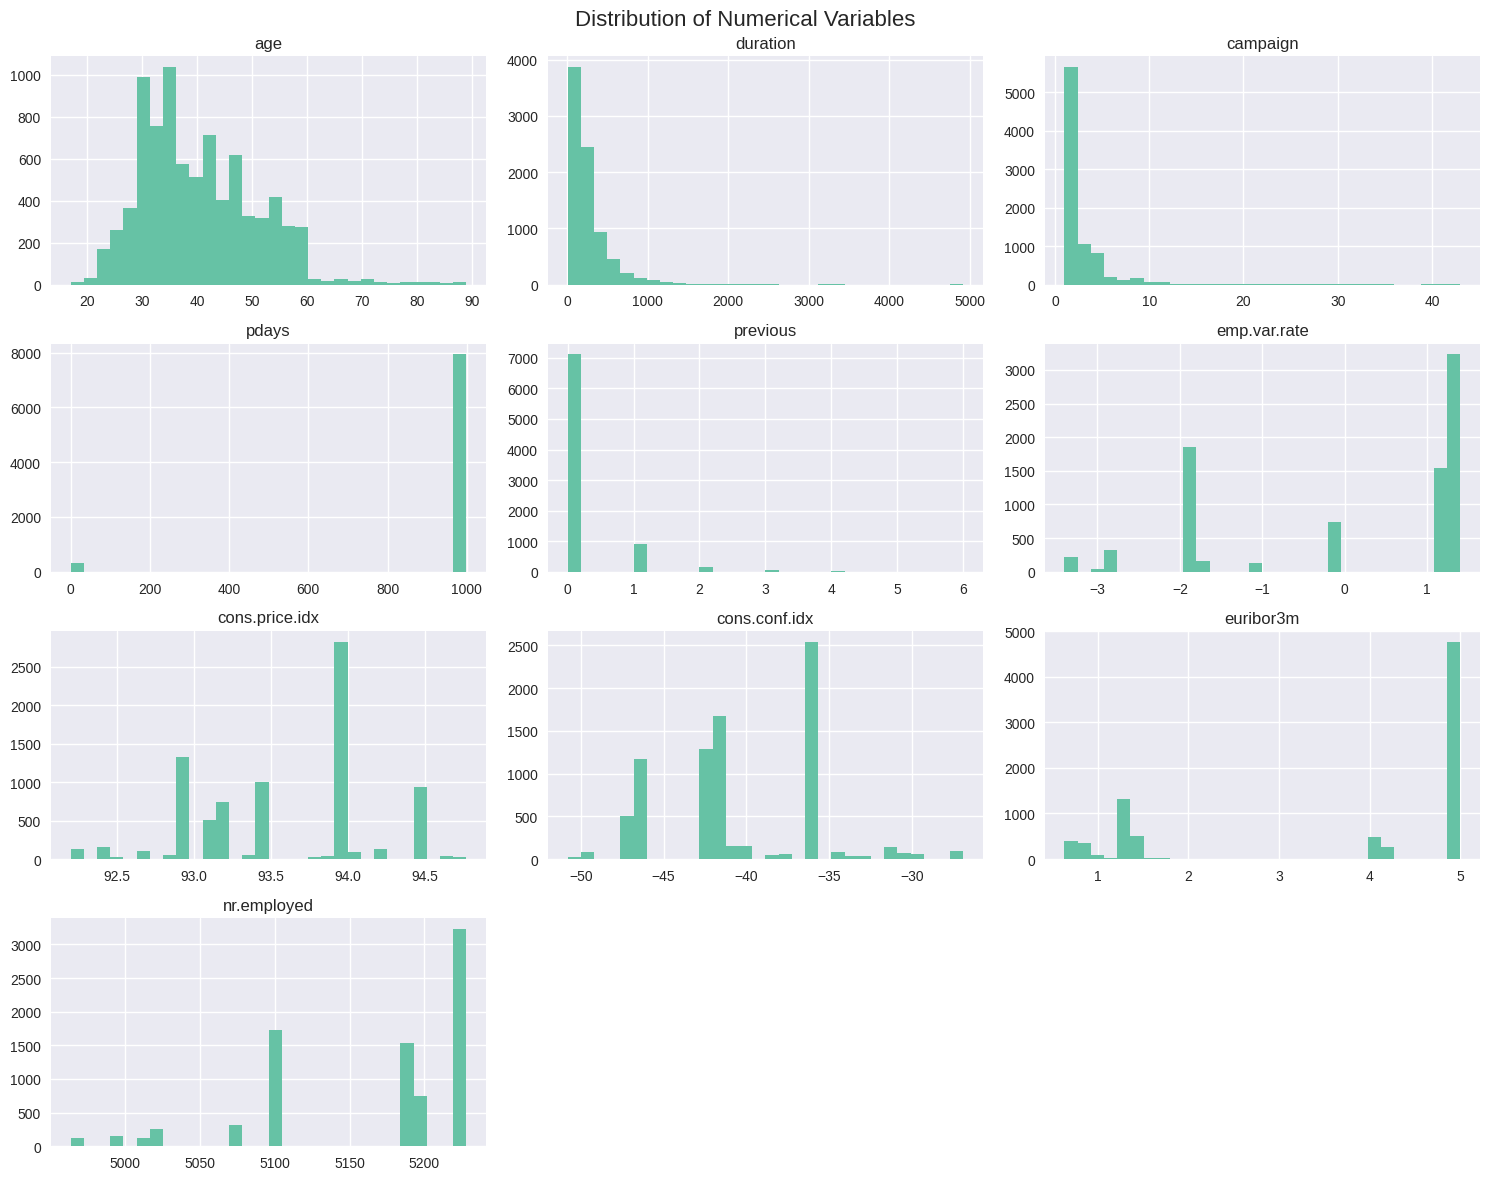

In [71]:
# Distribution of numerical variables
df[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)
plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)
plt.tight_layout()
plt.show()

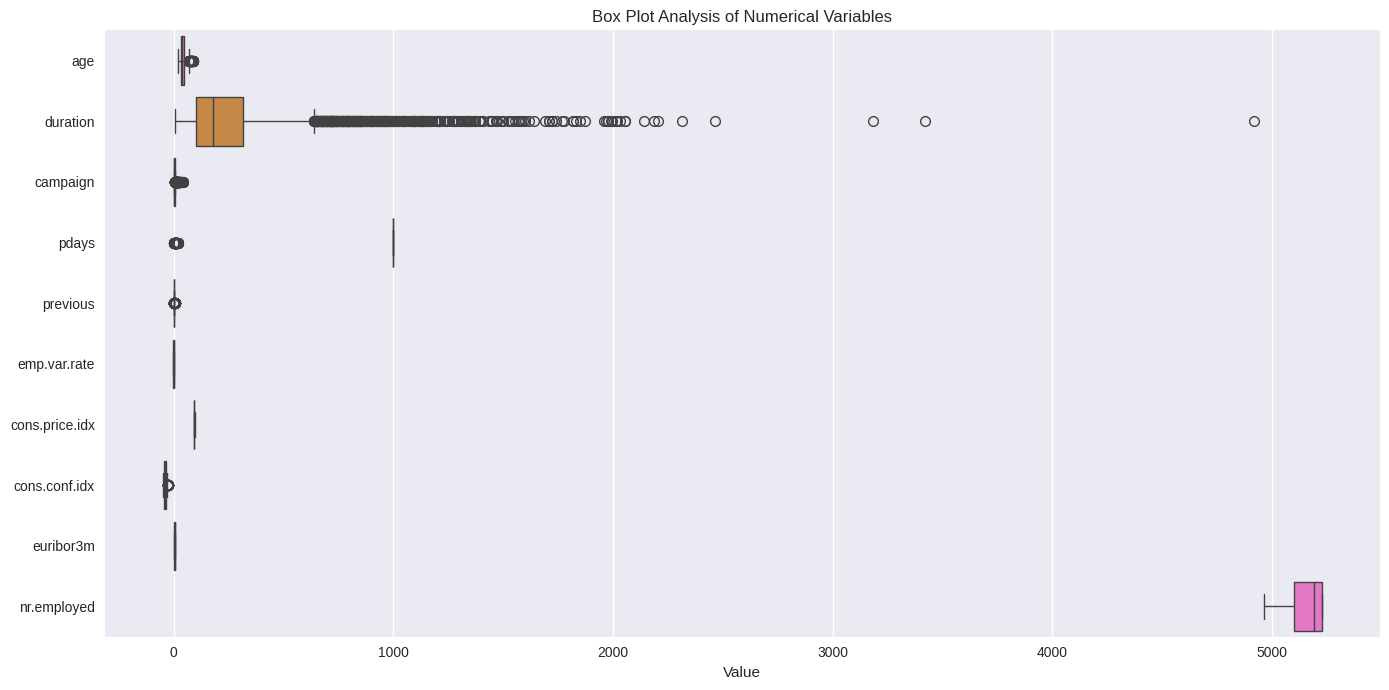

In [72]:
# Box plots for numerical variables
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df[numeric_cols],
    orient='h'
)
plt.title("Box Plot Analysis of Numerical Variables")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

In [73]:
# Shapiro-Wilk normality test

from scipy.stats import shapiro

normality_results = []

for col in numeric_cols:
    sample = df[col].dropna()

    # Shapiro-Wilk works best with a manageable sample size
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)

    statistic, p_value = shapiro(sample)

    normality_results.append({
        'Variable': col,
        'Statistic': statistic,
        'p-value': p_value,
        'Interpretation':
            'Approximately Normal' if p_value > 0.05
            else 'Not Normally Distributed'
    })

normality_df = pd.DataFrame(normality_results)

display(normality_df.round(5))

,Variable,Statistic,p-value,Interpretation
0,age,0.95473,0.0,Not Normally Distributed
1,duration,0.70184,0.0,Not Normally Distributed
2,campaign,0.54509,0.0,Not Normally Distributed
3,pdays,0.18028,0.0,Not Normally Distributed
4,previous,0.39294,0.0,Not Normally Distributed
5,emp.var.rate,0.76343,0.0,Not Normally Distributed
6,cons.price.idx,0.93299,0.0,Not Normally Distributed
7,cons.conf.idx,0.92099,0.0,Not Normally Distributed
8,euribor3m,0.68839,0.0,Not Normally Distributed
9,nr.employed,0.78932,0.0,Not Normally Distributed


## 2. 2D Statistical Analysis

Two-dimensional statistical analysis examines the relationship between two variables. Pearson and Spearman correlation are used for numerical variables, while t-test, chi-square test and ANOVA are used to examine relationships between numerical and categorical variables.

In [74]:
# Pearson Correlation Analysis
numeric_cols = df.select_dtypes(include='number').columns
pearson_corr = df[numeric_cols].corr(method='pearson')
print("Pearson Correlation Matrix:")
display(pearson_corr.round(3))

Pearson Correlation Matrix:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000,-0.001,-0.001,-0.029,0.016,0.013,0.015,0.125,0.022,-0.012
duration,-0.001,1.000,-0.076,-0.041,0.015,-0.023,0.006,-0.008,-0.028,-0.038
campaign,-0.001,-0.076,1.000,0.053,-0.081,0.152,0.134,-0.013,0.137,0.146
pdays,-0.029,-0.041,0.053,1.000,-0.587,0.269,0.082,-0.101,0.295,0.372
previous,0.016,0.015,-0.081,-0.587,1.000,-0.413,-0.199,-0.048,-0.450,-0.498
emp.var.rate,0.013,-0.023,0.152,0.269,-0.413,1.000,0.776,0.198,0.972,0.907
cons.price.idx,0.015,0.006,0.134,0.082,-0.199,0.776,1.000,0.064,0.689,0.525
cons.conf.idx,0.125,-0.008,-0.013,-0.101,-0.048,0.198,0.064,1.000,0.281,0.099
euribor3m,0.022,-0.028,0.137,0.295,-0.450,0.972,0.689,0.281,1.000,0.945
nr.employed,-0.012,-0.038,0.146,0.372,-0.498,0.907,0.525,0.099,0.945,1.000


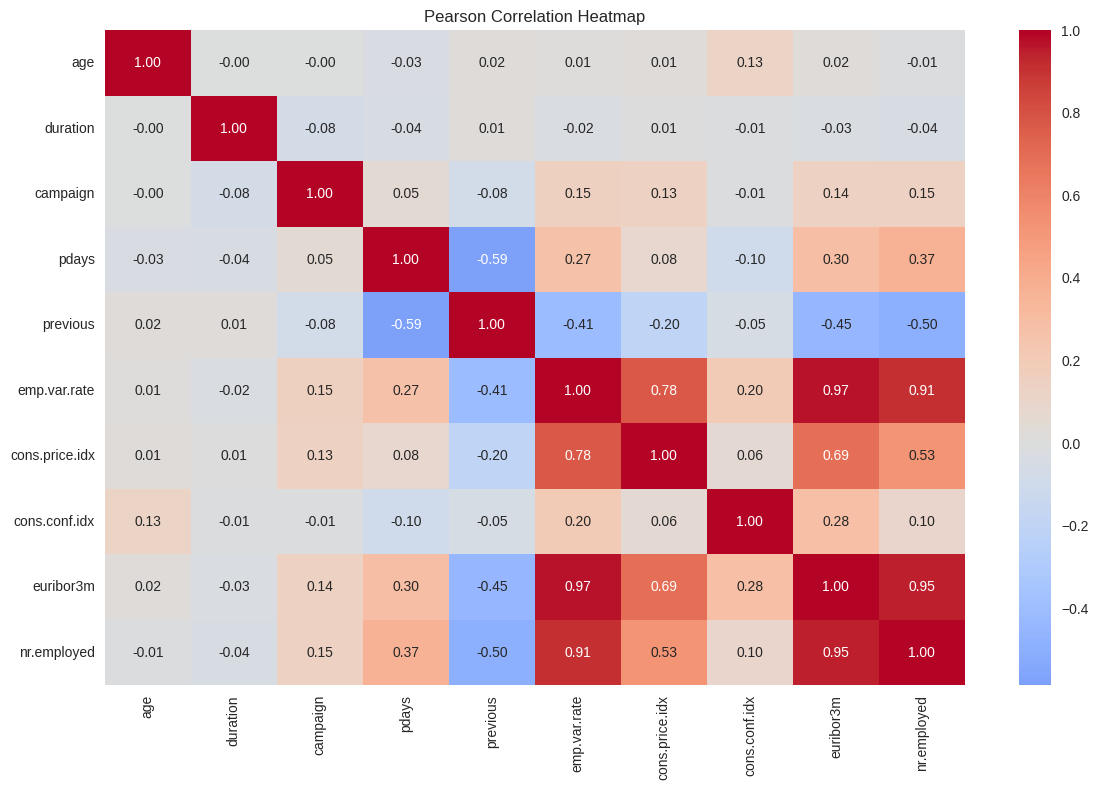

In [75]:
# Pearson Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [76]:
# Find the strongest numerical relationships
corr_pairs = pearson_corr.where(
    np.triu(
        np.ones(pearson_corr.shape),
        k=1
    ).astype(bool)
).stack()
corr_pairs = corr_pairs.sort_values(
    key=abs,
    ascending=False
)
print("Strongest correlations:")
display(corr_pairs.head(10).to_frame('Correlation'))

Strongest correlations:


Correlation
emp.var.rate   euribor3m          0.972425
euribor3m      nr.employed        0.945023
emp.var.rate   nr.employed        0.907159
               cons.price.idx     0.776435
cons.price.idx euribor3m          0.689206
pdays          previous          -0.586712
cons.price.idx nr.employed        0.525348
previous       nr.employed       -0.497720
               euribor3m         -0.449589
               emp.var.rate      -0.413494

In [77]:
# Spearman Rank Correlation
spearman_corr = df[numeric_cols].corr(
    method='spearman'
)
print("Spearman Correlation Matrix:")
display(spearman_corr.round(3))

Spearman Correlation Matrix:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000,-0.014,-0.003,0.000,-0.010,0.050,0.059,0.111,0.060,0.044
duration,-0.014,1.000,-0.086,-0.081,0.035,-0.067,0.010,-0.002,-0.074,-0.095
campaign,-0.003,-0.086,1.000,0.051,-0.090,0.150,0.104,0.003,0.129,0.140
pdays,0.000,-0.081,0.051,1.000,-0.511,0.227,0.059,-0.084,0.279,0.291
previous,-0.010,0.035,-0.090,-0.511,1.000,-0.432,-0.282,-0.117,-0.451,-0.436
emp.var.rate,0.050,-0.067,0.150,0.227,-0.432,1.000,0.677,0.234,0.941,0.944
cons.price.idx,0.059,0.010,0.104,0.059,-0.282,0.677,1.000,0.258,0.503,0.478
cons.conf.idx,0.111,-0.002,0.003,-0.084,-0.117,0.234,0.258,1.000,0.242,0.138
euribor3m,0.060,-0.074,0.129,0.279,-0.451,0.941,0.503,0.242,1.000,0.930
nr.employed,0.044,-0.095,0.140,0.291,-0.436,0.944,0.478,0.138,0.930,1.000


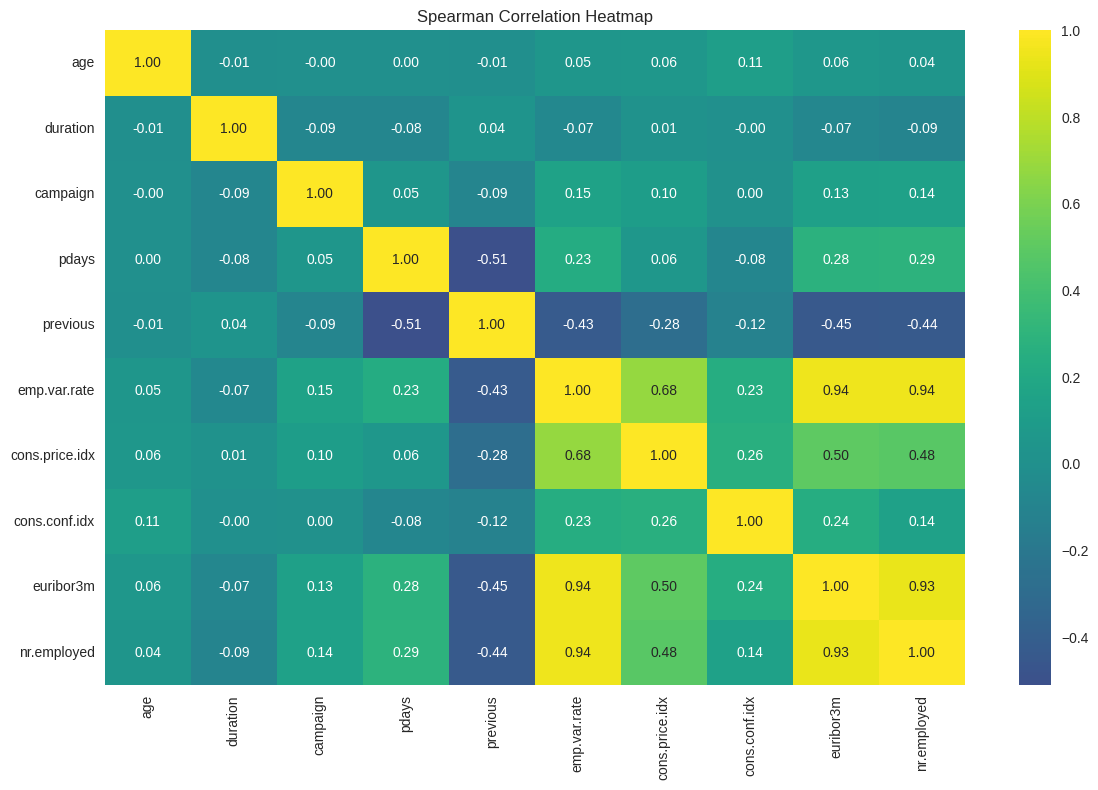

In [78]:
# Spearman Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    center=0
)
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

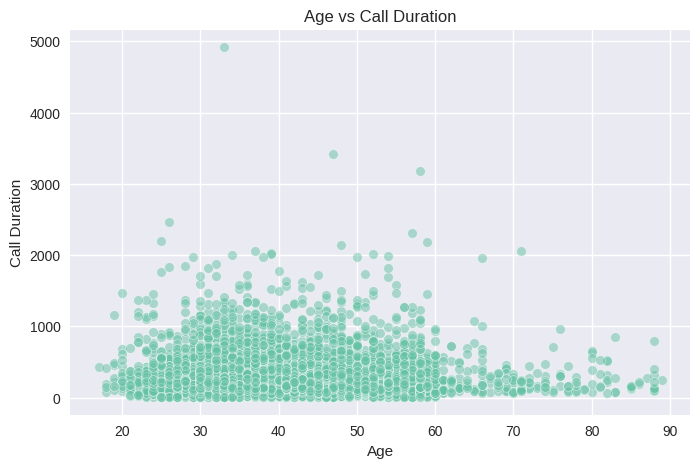

In [79]:
# Scatter Plot: Age vs Duration
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='age',
    y='duration',
    alpha=0.5
)
plt.title('Age vs Call Duration')
plt.xlabel('Age')
plt.ylabel('Call Duration')
plt.show()

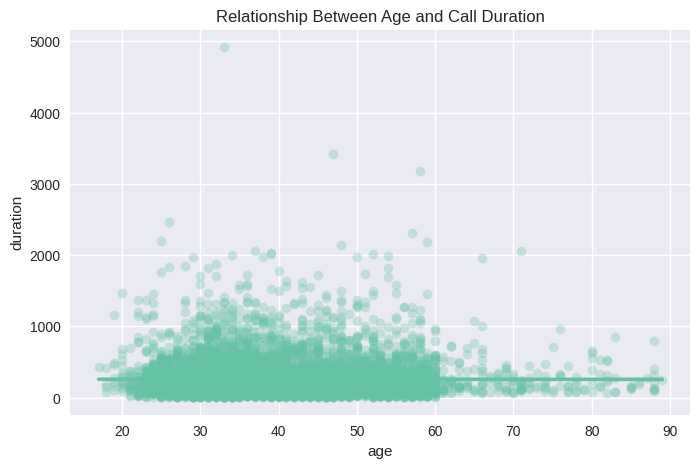

In [80]:
# Regression Plot: Age vs Duration
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='age',
    y='duration',
    scatter_kws={'alpha': 0.3}
)
plt.title('Relationship Between Age and Call Duration')
plt.show()

In [81]:
# Independent Samples t-test

from scipy.stats import ttest_ind

groups = df['y'].dropna().unique()

print("Outcome groups:", groups)

if len(groups) == 2:

    group1 = df[df['y'] == groups[0]]['duration']
    group2 = df[df['y'] == groups[1]]['duration']

    t_stat, p_value = ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    print("t-statistic:", round(t_stat, 4))
    print("p-value:", round(p_value, 6))

    if p_value < 0.05:
        print("Result: Statistically significant difference between the two groups.")
    else:
        print("Result: No statistically significant difference between the two groups.")

Outcome groups: ['no' 'yes']
t-statistic: -24.3908
p-value: 0.0
Result: Statistically significant difference between the two groups.


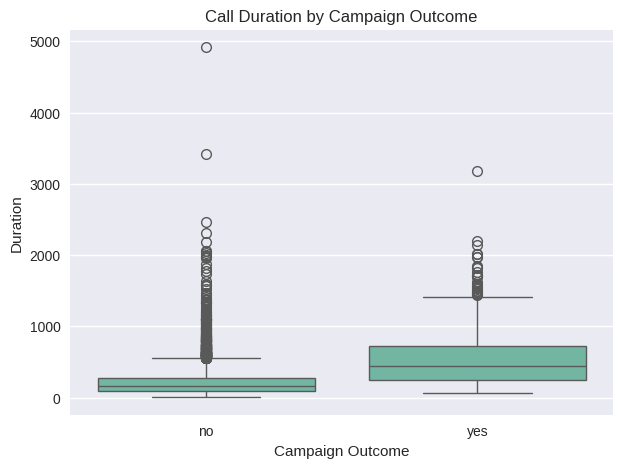

In [82]:
# Box Plot for t-test groups

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='y',
    y='duration'
)

plt.title('Call Duration by Campaign Outcome')
plt.xlabel('Campaign Outcome')
plt.ylabel('Duration')

plt.show()

In [83]:
# Chi-Square Test of Independence

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['job'],
    df['y']
)

print("Contingency Table:")
display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", dof)
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: There is a statistically significant association between job and campaign outcome.")
else:
    print("Result: No statistically significant association was detected.")

Contingency Table:


y,no,yes
job,,
admin.,1839,276
blue-collar,1744,122
entrepreneur,257,27
housemaid,209,13
management,566,67
retired,236,88
self-employed,233,22
services,698,65
student,103,65


Chi-square statistic: 272.81
Degrees of freedom: 11
p-value: 0.0
Result: There is a statistically significant association between job and campaign outcome.


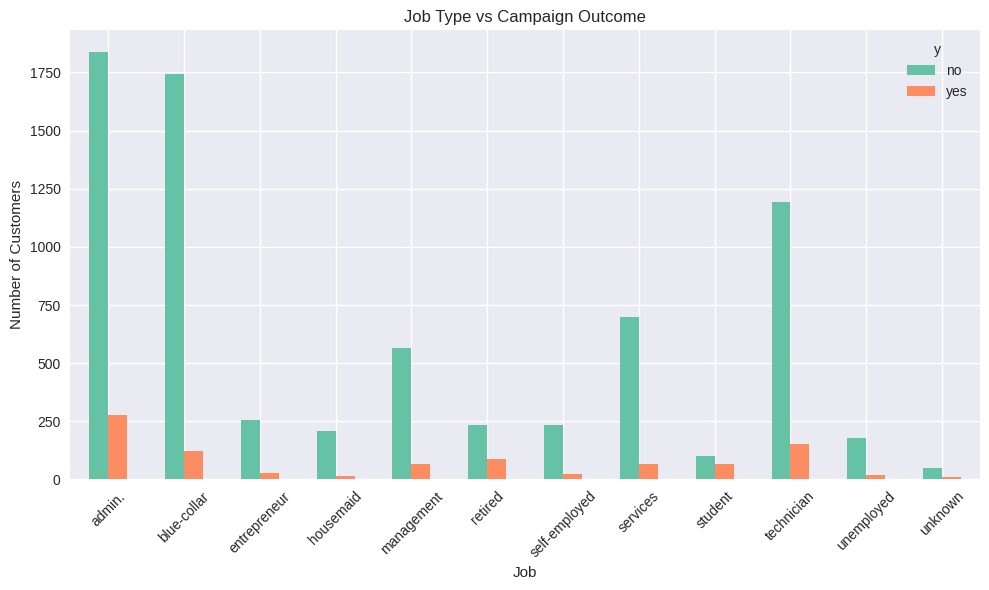

In [84]:
# Job vs Campaign Outcome

contingency_table.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Job Type vs Campaign Outcome')
plt.xlabel('Job')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
# One-Way ANOVA

from scipy.stats import f_oneway

education_groups = []

for education, group in df.groupby('education'):
    if len(group) >= 2:
        education_groups.append(group['duration'].dropna())

f_stat, p_value = f_oneway(
    *education_groups
)

print("ANOVA F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: At least one education group has a statistically different mean duration.")
else:
    print("Result: No statistically significant difference detected among education groups.")

ANOVA F-statistic: 0.9739
p-value: 0.448199
Result: No statistically significant difference detected among education groups.


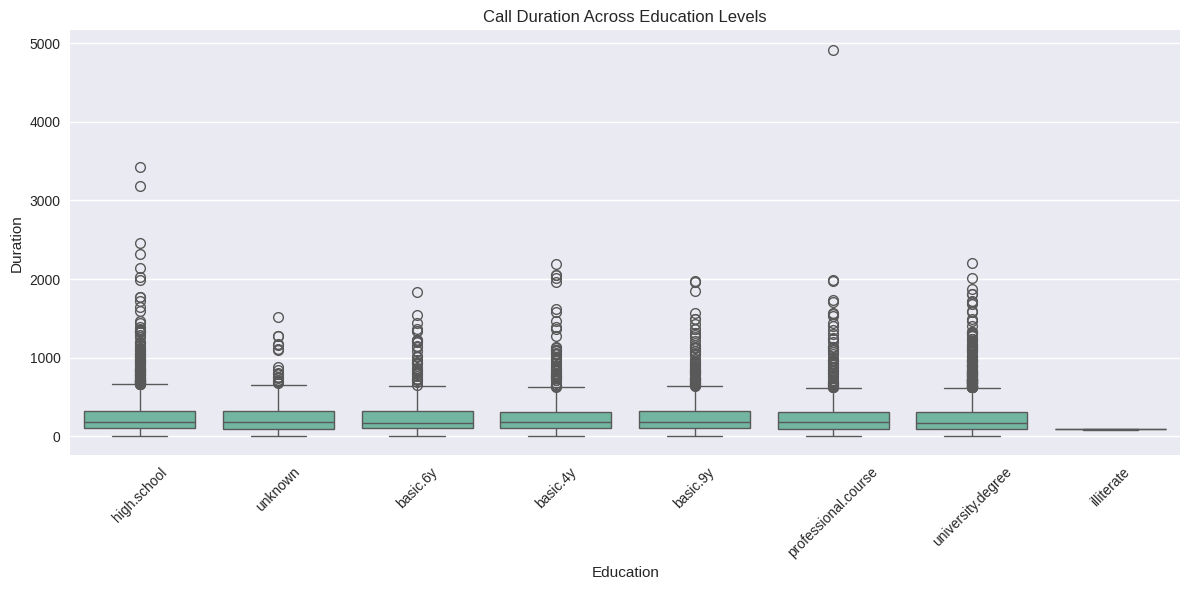

In [86]:
# Education vs Call Duration

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='education',
    y='duration'
)

plt.title('Call Duration Across Education Levels')
plt.xlabel('Education')
plt.ylabel('Duration')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. 3D Statistical Analysis

Three-dimensional statistical analysis examines the relationship among three numerical variables simultaneously. A 3D scatter plot is used to visualize the combined relationship between age, call duration and number of contacts.

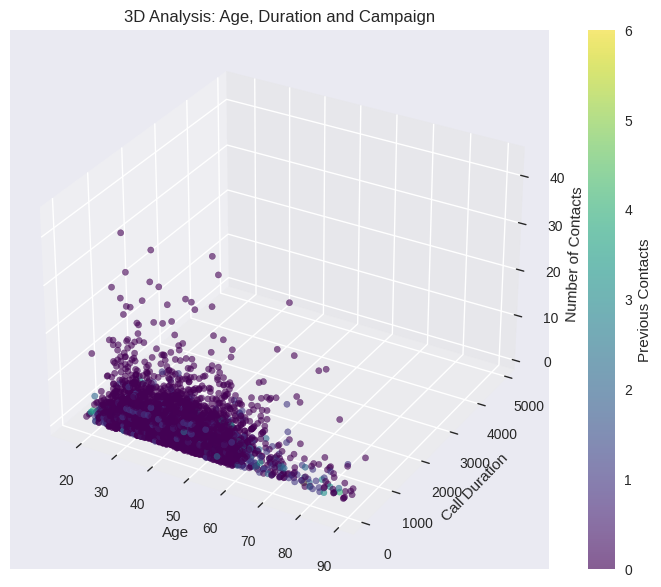

In [87]:
# 3D Scatter Plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['age'],
    df['duration'],
    df['campaign'],
    c=df['previous'],
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('Age')
ax.set_ylabel('Call Duration')
ax.set_zlabel('Number of Contacts')

ax.set_title(
    '3D Analysis: Age, Duration and Campaign'
)

fig.colorbar(
    scatter,
    ax=ax,
    label='Previous Contacts'
)

plt.show()

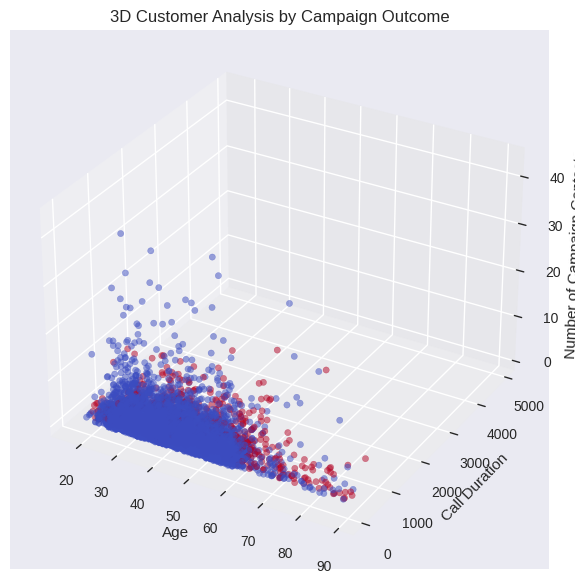

In [88]:
# Convert campaign outcome to numerical values for visualization

df['y_numeric'] = df['y'].map({
    'no': 0,
    'yes': 1
})

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['age'],
    df['duration'],
    df['campaign'],
    c=df['y_numeric'],
    cmap='coolwarm',
    alpha=0.5
)

ax.set_xlabel('Age')
ax.set_ylabel('Call Duration')
ax.set_zlabel('Number of Campaign Contacts')

ax.set_title(
    '3D Customer Analysis by Campaign Outcome'
)

plt.show()

In [89]:
# Multiple Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

features = [
    'age',
    'campaign',
    'previous'
]

target = 'duration'

X = df[features]
y_reg = df[target]

model = LinearRegression()

model.fit(X, y_reg)

predictions = model.predict(X)

print("Multiple Linear Regression")
print("--------------------------")

for feature, coefficient in zip(
    features,
    model.coef_
):
    print(
        feature,
        "coefficient =",
        round(coefficient, 4)
    )

print(
    "Intercept =",
    round(model.intercept_, 4)
)

r2 = r2_score(
    y_reg,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg,
        predictions
    )
)

print("R² =", round(r2, 4))
print("RMSE =", round(rmse, 4))

Multiple Linear Regression
--------------------------
age coefficient = -0.0339
campaign coefficient = -6.7506
previous coefficient = 4.4589
Intercept = 274.2174
R² = 0.0059
RMSE = 258.9582


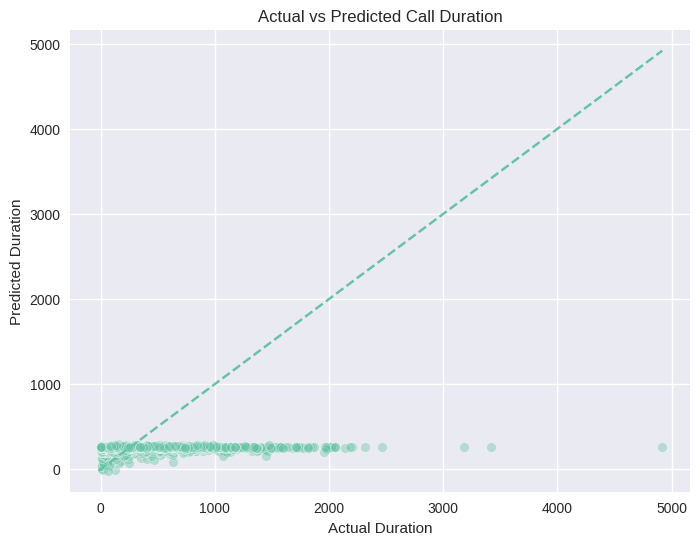

In [90]:
# Actual vs Predicted Duration

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_reg,
    y=predictions,
    alpha=0.4
)

plt.xlabel('Actual Duration')
plt.ylabel('Predicted Duration')

plt.title(
    'Actual vs Predicted Call Duration'
)

# Perfect prediction reference line
min_value = min(y_reg.min(), predictions.min())
max_value = max(y_reg.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.show()

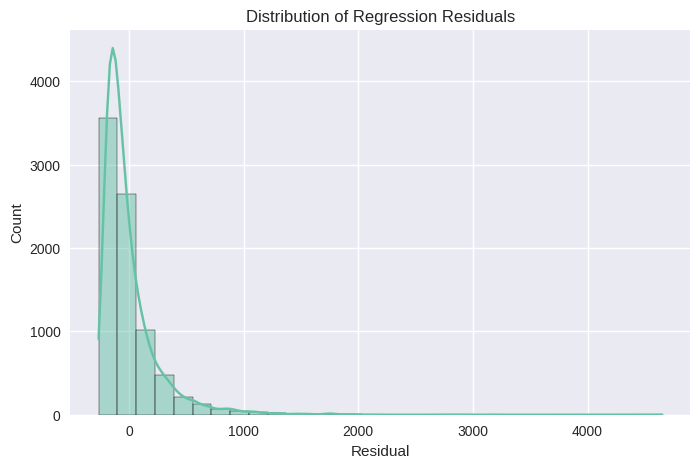

In [91]:
# Regression Residual Analysis

residuals = y_reg - predictions

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(
    'Distribution of Regression Residuals'
)

plt.xlabel('Residual')

plt.show()

,age,campaign,previous
age,1.000,-0.001,0.016
campaign,-0.001,1.000,-0.081
previous,0.016,-0.081,1.000


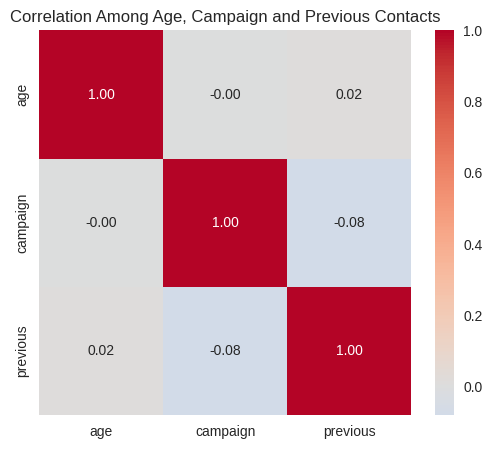

In [92]:
# Correlation among the three variables

three_variable_corr = df[
    ['age', 'campaign', 'previous']
].corr()

display(
    three_variable_corr.round(3)
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    three_variable_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Among Age, Campaign and Previous Contacts'
)

plt.show()

In [93]:
# K-Means Clustering - Select Numerical Features

cluster_cols = [
    'age',
    'duration',
    'campaign',
    'previous',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

cluster_data = df[cluster_cols].copy()

print("Variables selected for clustering:")
print(cluster_cols)

display(cluster_data.head())

Variables selected for clustering:
['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0
1,41,217,1,0,1.1,93.994,-36.4,4.857,5191.0
2,25,222,1,0,1.1,93.994,-36.4,4.857,5191.0
3,35,312,1,0,1.1,93.994,-36.4,4.857,5191.0
4,46,440,1,0,1.1,93.994,-36.4,4.857,5191.0


In [94]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_data)

print("Original shape:", cluster_data.shape)
print("Scaled shape:", X_scaled.shape)

print("\nFirst 5 standardized rows:")
display(
    pd.DataFrame(
        X_scaled,
        columns=cluster_cols
    ).head()
)

Original shape: (8235, 9)
Scaled shape: (8235, 9)

First 5 standardized rows:


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.519151,0.196162,-0.550504,-0.348346,0.654022,0.714801,0.897498,0.719376,0.336761
1,0.084998,-0.150354,-0.550504,-0.348346,0.654022,0.714801,0.897498,0.719376,0.336761
2,-1.444764,-0.131103,-0.550504,-0.348346,0.654022,0.714801,0.897498,0.719376,0.336761
3,-0.488662,0.215412,-0.550504,-0.348346,0.654022,0.714801,0.897498,0.719376,0.336761
4,0.563049,0.708235,-0.550504,-0.348346,0.654022,0.714801,0.897498,0.719376,0.336761


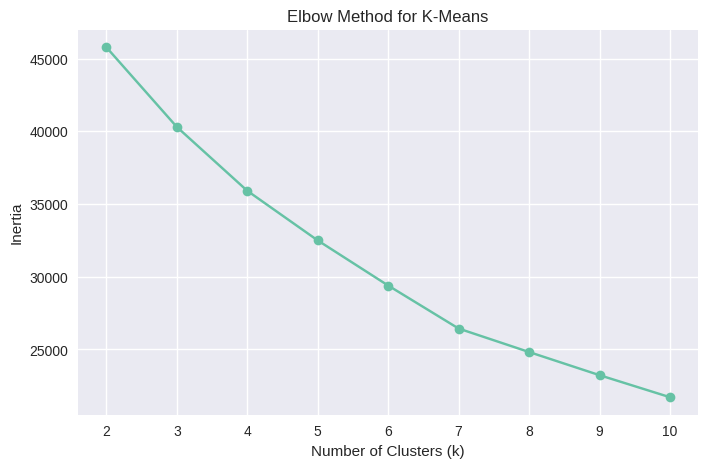

In [95]:
# Elbow Method

from sklearn.cluster import KMeans

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')

plt.xticks(k_values)

plt.show()

In [96]:
# Silhouette Score

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    'Number of Clusters': list(k_values),
    'Silhouette Score': silhouette_scores
})

display(
    silhouette_df.round(4)
)

,Number of Clusters,Silhouette Score
0,2,0.4335
1,3,0.4184
2,4,0.4041
3,5,0.3690
4,6,0.3467
5,7,0.2690
6,8,0.2562
7,9,0.2397
8,10,0.2657


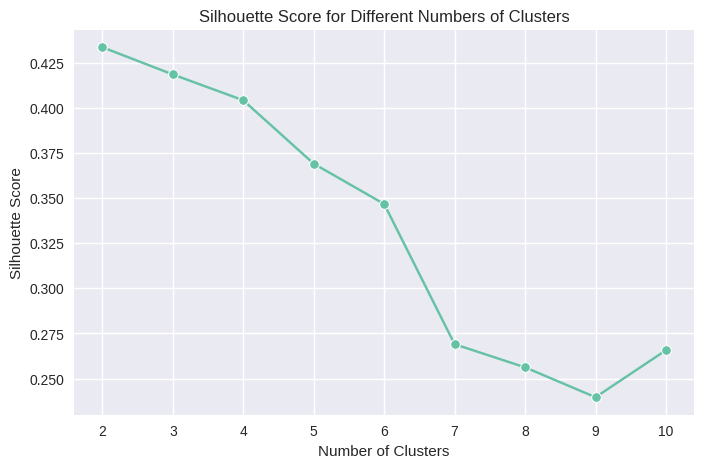

In [97]:
# Silhouette Score Visualization

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=silhouette_df,
    x='Number of Clusters',
    y='Silhouette Score',
    marker='o'
)

plt.title('Silhouette Score for Different Numbers of Clusters')

plt.show()

In [98]:
# Select k based on the highest silhouette score

best_k = int(
    silhouette_df.loc[
        silhouette_df['Silhouette Score'].idxmax(),
        'Number of Clusters'
    ]
)

print("Selected number of clusters:", best_k)

print(
    "Highest silhouette score:",
    round(
        silhouette_df['Silhouette Score'].max(),
        4
    )
)

Selected number of clusters: 2
Highest silhouette score: 0.4335


In [99]:
# Final K-Means Model

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans_final.fit_predict(
    X_scaled
)

print("K-Means clustering completed.")

K-Means clustering completed.


In [100]:
# Number of observations in each cluster

cluster_counts = df[
    'KMeans_Cluster'
].value_counts().sort_index()

print("Customers in each K-Means cluster:")

display(
    cluster_counts.to_frame(
        'Number of Customers'
    )
)

Customers in each K-Means cluster:


,Number of Customers
KMeans_Cluster,
0,5510
1,2725


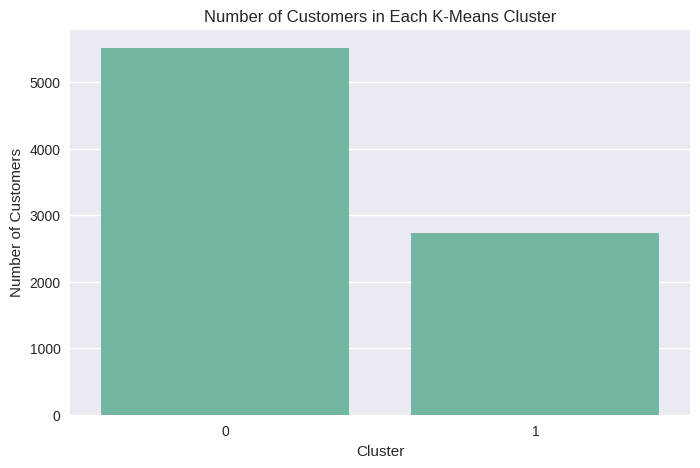

In [101]:
# K-Means Cluster Size Visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.title(
    'Number of Customers in Each K-Means Cluster'
)

plt.show()

In [102]:
# K-Means Cluster Profiles

cluster_profile = df.groupby(
    'KMeans_Cluster'
)[cluster_cols].mean()

display(
    cluster_profile.round(2)
)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
KMeans_Cluster,,,,,,,,,
0,40.36,250.76,2.86,0.03,1.11,93.85,-39.49,4.81,5213.38
1,39.60,266.75,2.09,0.47,-2.04,93.03,-42.68,1.17,5072.00


In [103]:
# PCA for K-Means Visualization

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['KMeans_Cluster'].astype(str)
})

print(
    "Variance explained by PC1:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "Variance explained by PC2:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Variance explained by PC1: 0.4156
Variance explained by PC2: 0.1258
Total variance explained: 0.5413


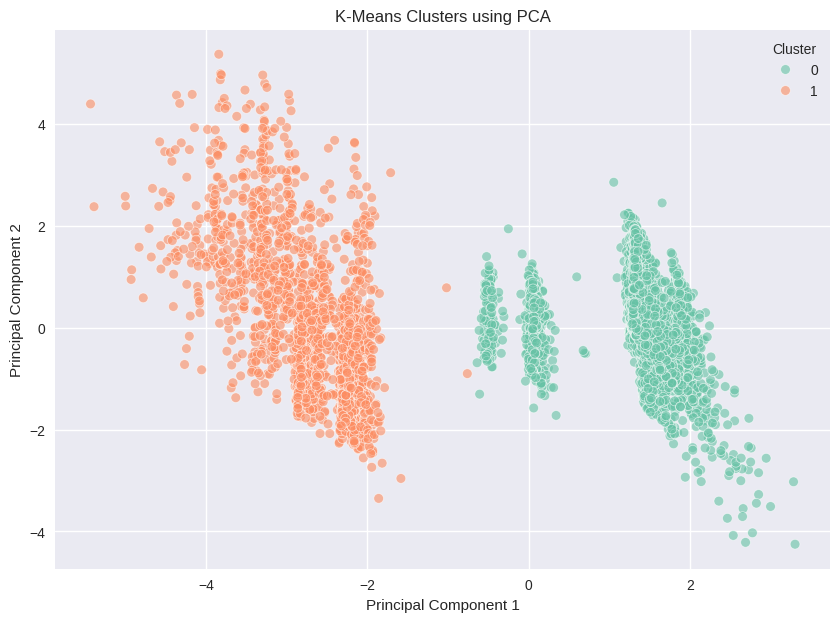

In [104]:
# K-Means PCA Cluster Visualization

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    alpha=0.6
)

plt.title(
    'K-Means Clusters using PCA'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [105]:
# Hierarchical Clustering Libraries

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [106]:
# Create a sample for the dendrogram

sample_size = min(1000, len(X_scaled))

np.random.seed(42)

sample_indices = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_hier_sample = X_scaled[sample_indices]

print("Observations used for dendrogram:", sample_size)

Observations used for dendrogram: 1000


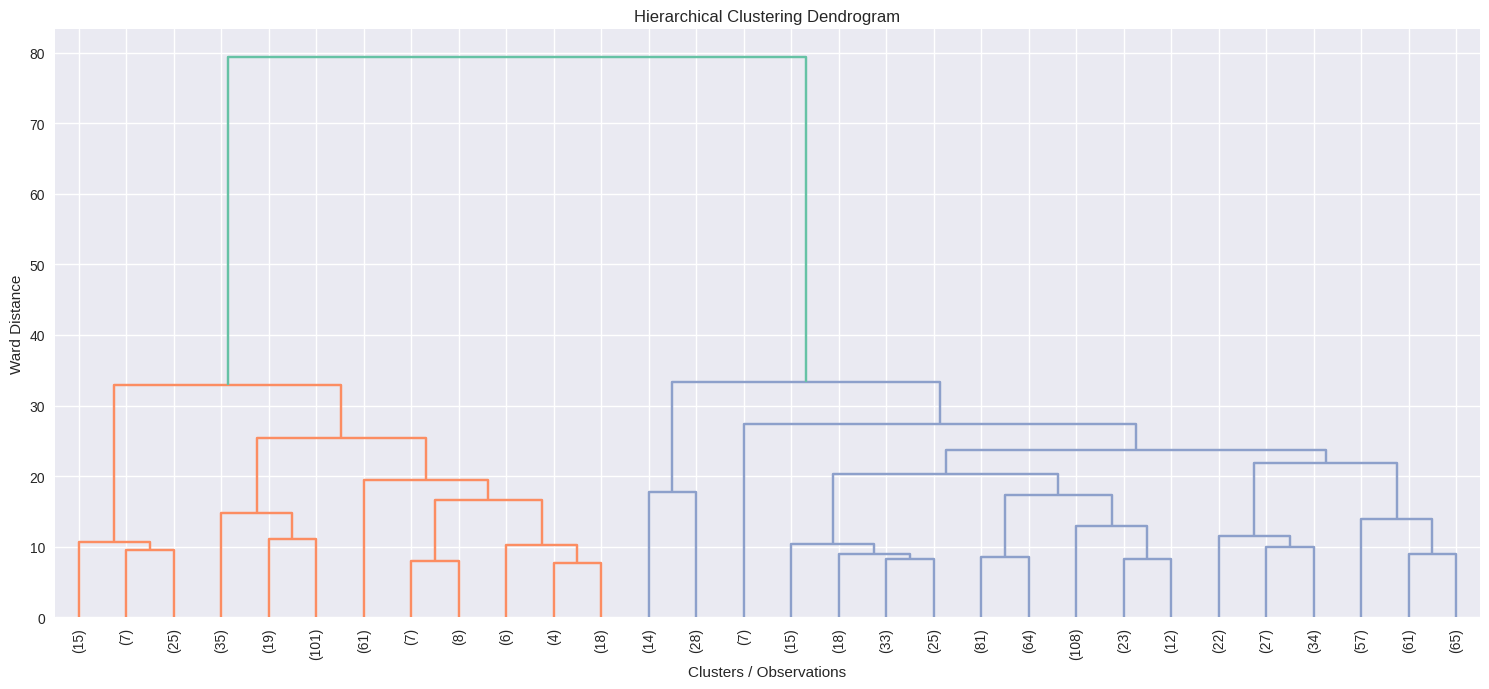

In [107]:
# Hierarchical Clustering Dendrogram

linkage_matrix = linkage(
    X_hier_sample,
    method='ward'
)

plt.figure(figsize=(15, 7))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title(
    'Hierarchical Clustering Dendrogram'
)

plt.xlabel(
    'Clusters / Observations'
)

plt.ylabel(
    'Ward Distance'
)

plt.tight_layout()

plt.show()

In [108]:
# Agglomerative Hierarchical Clustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

df['Hierarchical_Cluster'] = (
    hierarchical_model.fit_predict(X_scaled)
)

print("Hierarchical clustering completed.")
print("Number of clusters:", best_k)

Hierarchical clustering completed.
Number of clusters: 2


In [109]:
# Number of observations in each hierarchical cluster

hierarchical_counts = (
    df['Hierarchical_Cluster']
    .value_counts()
    .sort_index()
)

print("Customers in each hierarchical cluster:")

display(
    hierarchical_counts.to_frame(
        'Number of Customers'
    )
)

Customers in each hierarchical cluster:


,Number of Customers
Hierarchical_Cluster,
0,2712
1,5523


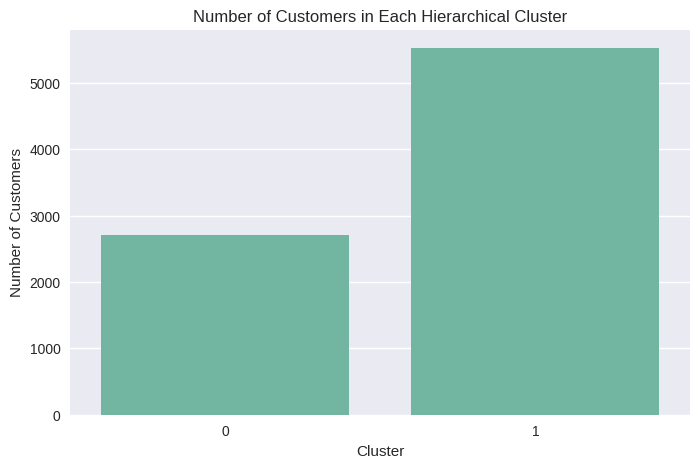

In [110]:
# Hierarchical Cluster Size Visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    x=hierarchical_counts.index,
    y=hierarchical_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.title(
    'Number of Customers in Each Hierarchical Cluster'
)

plt.show()

In [111]:
# Hierarchical Cluster Profiles

hierarchical_profile = (
    df.groupby('Hierarchical_Cluster')[cluster_cols]
    .mean()
)

display(
    hierarchical_profile.round(2)
)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
Hierarchical_Cluster,,,,,,,,,
0,39.56,259.87,2.09,0.47,-2.04,93.03,-42.68,1.17,5071.87
1,40.38,254.18,2.86,0.03,1.11,93.85,-39.50,4.81,5213.12


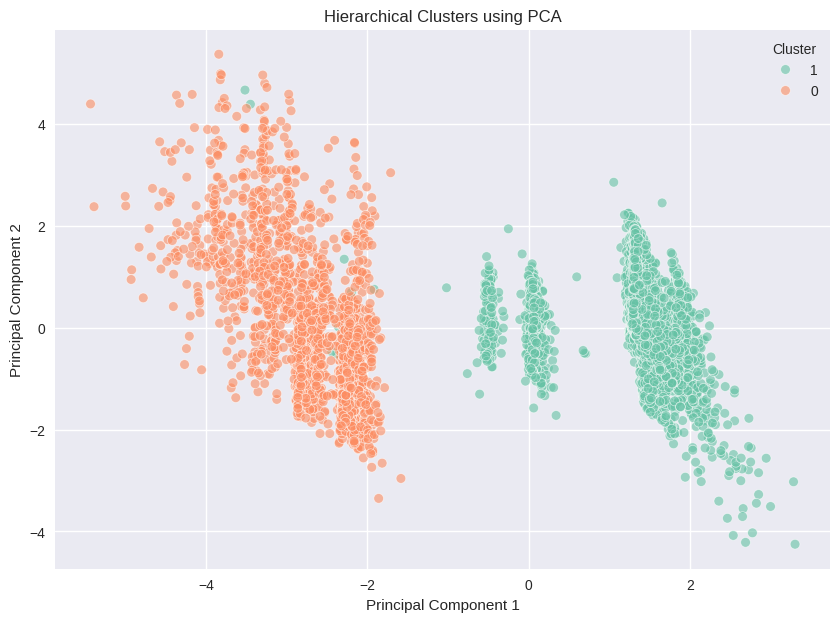

In [112]:
# PCA Visualization of Hierarchical Clusters

hierarchical_pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['Hierarchical_Cluster'].astype(str)
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=hierarchical_pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    alpha=0.6
)

plt.title(
    'Hierarchical Clusters using PCA'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [113]:
# Hierarchical Clustering Silhouette Score

hierarchical_silhouette = silhouette_score(
    X_scaled,
    df['Hierarchical_Cluster']
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score: 0.4322


In [114]:
# Compare K-Means and Hierarchical Clustering

kmeans_silhouette = silhouette_score(
    X_scaled,
    df['KMeans_Cluster']
)

comparison = pd.DataFrame({
    'Method': [
        'K-Means',
        'Hierarchical'
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

display(
    comparison.round(4)
)

,Method,Silhouette Score
0,K-Means,0.4335
1,Hierarchical,0.4322


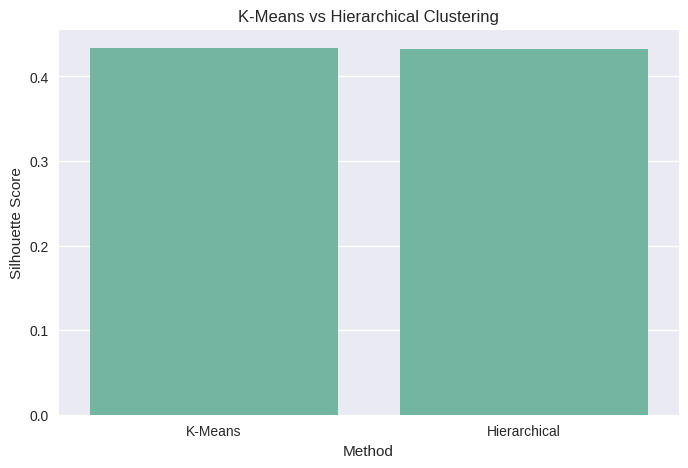

In [115]:
# Clustering Method Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Method',
    y='Silhouette Score'
)

plt.title(
    'K-Means vs Hierarchical Clustering'
)

plt.ylabel('Silhouette Score')

plt.show()

# 7. Phase 2 Conclusion

Phase 2 extended the Phase 1 exploratory analysis through detailed one-dimensional, two-dimensional and three-dimensional statistical analysis.

The statistical analysis included descriptive statistics, correlation analysis, hypothesis testing, and multiple linear regression.

K-Means clustering was performed after standardizing the numerical variables. The Elbow Method and Silhouette Score were used to examine the clustering structure. Hierarchical clustering was then performed using Ward linkage, with a dendrogram used to visualize the hierarchical structure.

Finally, the K-Means and Hierarchical clustering results were compared using silhouette scores and PCA-based visualizations.